In [148]:
''' Import required packages
'''

import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import numba
from scipy.stats import norm
from numba import njit
numba.config.FULL_TRACEBACKS = True

In [ ]:
''' Sampling from the non-linear state-space model with
equations x_t+1 = atan(x_t) + theta_1 * u_t + v_t, v_t ~ N(0,1)
          y_t   = |x_t| + theta_1 * theta_2 + e_t, e_t ~ N(0,0.01).
True parameters used for sampling are not given explicitly in the
paper, so let us pick these ourselves: theta_1 = -1, theta_2 = 0.8.
'''

@njit
def g(x, theta):
    """ Deterministic part of the
    distribution ``p(y_t|x_t,theta)`` in the
    state-space model described above.
    
    Parameters
    -
    x              : float
                     Latent space variable
    theta          : ndarray of shape (2,)
                     Parameters for the state-space model
                     
    Returns
    -
    Deterministic part of observation
    """
    return np.abs(x) + theta[0] * theta[1]

@njit
def f(x, theta, u):
    """ Deterministic part of the
    distribution ``p(x_t|x_t-1,theta)`` in the
    state-space model described above.
    
    Parameters
    -
    x              : float
                     Previous latent-space state
    theta          : ndarray of shape (2,)
                     Parameters for the state-space model
    u              : float
                     Previous exogenous input parameter
    
    Returns
    -
    Deterministic part of next latent-space state
    """
    return np.atan(x) + theta[0] + u

    

def sample_state_space_model(us, T=200, theta=np.asarray([-1,0.8])):
    """Sample observations from the non-linear
    state-space model described in Svensson et al. (2017).

    Parameters
    -
    T : int, default=500
        Number of time steps to simulate.
    theta : ndarray of shape (2,):
        Parameters of underlying state-space model.
    us : ndarray of shape (T,):
        List of exogenous input variables.

    Returns
    -
    ys : ndarray of shape (T,)
        Simulated observations generated from the state space model.
    """

    xs = np.zeros((T,)) # Storage for latent states
    ys = np.zeros((T,)) # Storage for observations
    xs[0] = 0 # Initial condition
    ys[0] = np.random.normal(g(xs[0], theta),0.01)
    for i in range(1, T):
        # Evolve latent space according to formula
        # in Svensson et al. (2017).
        xs[i] = np.random.normal(f(xs[i-1],theta,us[i-1]), 1)
        ys[i] = np.random.normal(g(xs[i],theta),0.01)
    return ys

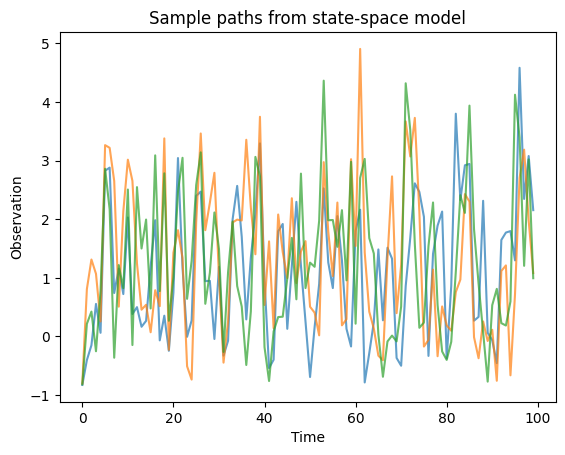

In [99]:
''' Draw sample paths from the state-space model defined above.
Do some quick visualization.
'''


n_paths = 3 # Number of paths to draw
T = 100 # Number of samples in each path

rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T) # Fixed exogenous input variables

for _ in range(n_paths):
    ys = sample_state_space_model(us=us,T=T,theta=np.asarray([-1,0.8]))
    plt.plot(ys, alpha=0.7)

plt.title("Sample paths from state-space model")
plt.xlabel("Time")
plt.ylabel("Observation")
plt.show()

In [178]:
""" Implementation of the bootstrap particle filter
for this non-linear state-space model.
"""

@njit
def normal_logpdf(x, loc, scale):
    """ Compute log pdf of normal distribution
    with mean loc and variance scale.
    """
    z = (x - loc) / scale
    return -0.5 * z*z - np.log(scale) - 0.5*np.log(2*np.pi) 

@njit
def logsumexp(x):
    """Fast numerically stable logsumexp
    """
    m = np.max(x)

    s = 0.0
    for i in range(len(x)):
        s += np.exp(x[i] - m)

    return m + np.log(s)


@njit
def multinomial_resample(weights):
    """Get resampled indices based on
    normalized weight vector.
    Fast njit-compatible version of
    multinomial resampling
    """
    N = len(weights)
    
    cdf = np.empty(N)

    cdf[0] = weights[0]

    for i in range(1, N):
        cdf[i] = cdf[i-1] + weights[i]

    out = np.empty(N, dtype=np.int64)

    for i in range(N):

        u = np.random.rand()
        out[i] = np.searchsorted(cdf, u)

    return out


@njit
def particle_filter(temp, n_particles, ys, us, theta):
    """ Bootstrap particle filter for the nonlinear
    state-space model defined above.
    
    Parameters
    -
    temp        : float
                  tempering parameter
    n_particles : int
                  number of particles to use
    ys          : ndarray of shape (T,)
                  List of observations from the 
                  underlying state-space model
    us          : ndarray of shape (T,)
                  List of exogenous input parameters
                  in the underlying state-space model
    theta       : ndarray of shape (2,)
                  Parameters of the underlying state-space
                  model
                  
    Returns
    -
    List of samples ``x_1:T`` of shape (n_particles,T) from the filtering
    distributions ``p(x_t|y_1:t,theta,temp)``, to be used
    in the approximation of the likelihood ``p(y_1:T|theta,temp)``
    
    List of internal resampling states ``a_2:T`` of shape (n_particlesT-1)
    """
    
    # Ensure consistent shape for theta to make
    # numba work
    theta = np.asarray(theta).reshape(2,)
    
    T = len(ys)
    xs = np.zeros(shape=(n_particles,T)) # Particle storage
    aas = np.zeros(shape=(n_particles,T-1),dtype=np.int64) # Resampling storage
    
    var = 0.01 + temp # Variance after tempering
    log_w = np.empty(n_particles) # Weight storage

    # Sample initial xs from ``p(x|theta)`` in the state-space model
    # Initial condition is just deterministically 0, so just set to 0
    xs[:,0] = np.zeros(n_particles)

    # Weight according to f(y_1|x_1,theta,temp) = N(|x_1| + theta1 * theta2, 0.01 + temp)
    # Recall: going from p(x|theta,temp) to p(x|y,theta,temp) = 
    # f(y|x,theta,temp)p(x|theta,temp) / p(y|theta,temp)
    # Recall: so up to x-proportionality, dQ(x)/dM(x) = f(y|x,theta,temp)    
    for i in range(n_particles):
        
        log_w[i] = normal_logpdf(ys[0],
                                 loc=g(xs[i,0],theta),
                                 scale=var)
    
    # Iterate over timesteps
    for t in range(1,T):
        
        # Normalize weights
        w_norm = np.exp(log_w - logsumexp(log_w))
        
        # Resample indices according to the normalized weights
        aas[:,t-1] = multinomial_resample(w_norm)
        
        # Extend
        for i in range(n_particles):
            
            xs[i,t] = np.random.normal(loc=f(xs[aas[i,t-1],t-1],
                                         theta=theta,
                                         u=us[t-1]),
                                       scale=1) 
                             
        # Reweight
        for i in range(n_particles):
            
            log_w[i] = normal_logpdf(ys[t],
                                     loc=g(xs[i,t],theta),
                                     scale=var)
    return xs, aas
    

In [ ]:
""" Implementation of particle Metropolis-Hastings (PMH)
for this state-space model.
"""

@njit
def log_prior(theta):
    """Compute prior probability of observing
    parameter theta.
    
    Parameters
    -
    theta : ndarray of shape (2,)
            Parameter of state-space model
    """
    if -2 <= theta[0] <= 2 and -2 <= theta[1] <= 2:
        return 0.0
    else:
        return -np.inf

@njit
def sample_prior(n=1):
    """Sample from uniform prior
    on theta.
    
    Parameters
    -
    n : int
        Number of samples to draw
    """
    return np.random.uniform(-2,2,size=(n,2))


@njit
def particle_metropolis_hastings(
    theta, 
    xs,
    aas, 
    us,
    ys,
    temp,
    n_iters=1, 
    proposal_sd=0.01, 
    verbose=False
    ):
    """Draw samples from the posterior ``p(theta|y_1:T,temp)`` 
    of the tempered non-linear state space model described above,
    using a random-walk particle Metropolis-Hastings algorithm with 
    bivariate normal proposal.
    
    Parameters
    -
    theta         : ndarray of shape (2,)
                    Initial parameter value
    xs            : ndarray of shape (n_particles,T)
                    Particles used for sampling the initial
                    parameter value
    aas           : ndarray of shape (n_particles,T-1)
                    Internal resampling state of the particle
                    filter used for sampling the initial parameter
                    value
    temp          : float
                    Tempering parameter of the distribution to sample
                    from.
    ys            : ndarray of shape (T,)
                    List of observations on which the distribution to
                    sample from is conditioned.
    n_iters       : int, default=1
                    Number of iterations to run the Metropolis-Hastings
                    algorithm for.
    proposal_sd   : float, default=0.01
                    Standard deviation of the proposal distribution.
    verbose       : Boolean, default=False
                    Whether or not to print additional diagnostic information
                    while running the algorithm
                    
    Returns
    -
    thetas : ndarray of shape (2,n_iters)
             List of M-H parameter samples
    xss    : ndarray of shape (n_particles,T,n_iters)
             List of internal particles for estimation of M-H samples
    aass   : ndarray of shape (n_particles,T-1,n_iters)
             List of internal particle filter resampling states for
             estimation of M-H samples
    """
    T = len(ys) # Number of observations
    n_particles = xs.shape[0] # Number of particles
    n_accepts = 0 # Keep track of acceptance rate
    var = 0.01 + temp # Observation variance after tempering
    
    # Keep track of all samples, including the initial sample
    thetas = np.zeros(shape=(n_iters+1,2))
    thetas[0] = theta.flatten()
    
    # Keep track of all internal states, including the initial state
    xss = np.zeros(shape=(n_particles,T,n_iters+1))
    aass = np.zeros(shape=(n_particles,T-1,n_iters+1),dtype=np.int64)
    xss[:,:,0] = xs
    aass[:,:,0] = aas
    
    # Estimate of the log likelihood ``log p(y_1:T|theta,temp)`` using the particle filter
    # This is just the log of the formula in the paper, using logsumexp
    # for speed, optimized for numba
    log_lik = 0.0
    for t in range(T):
        inner = np.empty(n_particles)
        for n in range(n_particles):
            inner[n] = normal_logpdf(ys[t],
                                     loc=g(xss[n,t,0],thetas[0]),
                                     scale=var)
        log_lik += logsumexp(inner)
    
    for i in range(1,n_iters+1):
        
        # Propose new parameter according to a
        # random walk proposal
        # We have to do it explicitly (without, for example,
        # np.multivariate_normal) to make it work
        # with numba. Worth it!
        eps0 = np.random.normal()
        eps1 = np.random.normal()
        new_theta = np.array([
            thetas[i-1, 0] + proposal_sd * eps0,
            thetas[i-1, 1] + proposal_sd * eps1
        ])
        
        # Run particle filter using this new parameter value
        new_xss, new_aass = particle_filter(temp=temp,
                                    n_particles=n_particles,
                                    ys=ys,
                                    us=us,
                                    theta=new_theta)

        # Use particle filter results to estimate the
        # log-likelihood for the newly proposed parameter        
        new_log_lik = 0.0
        for t in range(T):
            inner = np.empty(n_particles)
            for n in range(n_particles):
                inner[n] = normal_logpdf(ys[t],
                                     loc=g(new_xss[n,t],new_theta),
                                     scale=var)
            new_log_lik += logsumexp(inner)

        
        # Sample value uniform on [0,1]
        d = np.random.uniform(0,1)
        
        # Compute log of the acceptance probability
        log_alpha = new_log_lik + log_prior(new_theta) - \
                    log_lik - log_prior(thetas[i-1])
        
        # If d < min(alpha,1), keep thetas[i], xss[:,:,i], aas[:,:,i] the same.
        # Otherwise, change them back to their previous values.
        if np.log(d) < min(log_alpha, 0):
            # Don't change anything here except log likelihood,
            # because 'updated' values are already placed in
            # thetas, xss, aas
            log_lik = new_log_lik
            xss[:,:,i] = new_xss
            aass[:,:,i] = new_aass
            thetas[i] = new_theta
            n_accepts += 1
        else:
            thetas[i] = thetas[i-1]
    
    accept_rate = n_accepts / n_iters
    return thetas[1:], xss[:,:,1:], aass[:,:,1:], accept_rate

Particle filter took 0.006186008453369141s
PMH took 1.1262152194976807s
Acceptance rate of initial PMH sample: 0.39


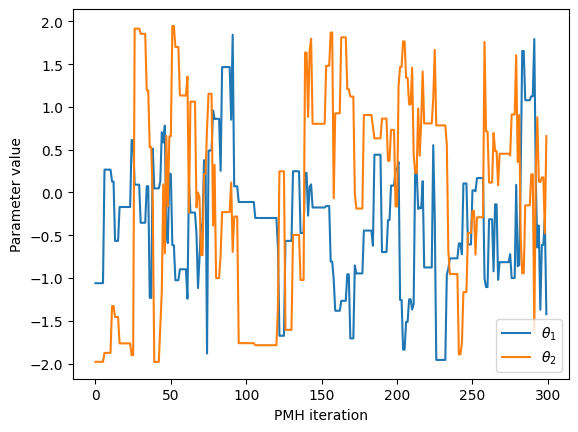

In [266]:
""" Test whether the PMH sampling works by sampling
an intiial estimate from the posterior p(theta|y_1:T,temp)
"""

temp = 10 # Initial tempering
T = 100 # Number of observations
                              
# Exogenous input variables
rng = np.random.default_rng(seed=42) # Want to fix this while keeping the rest random
us = rng.normal(loc=0, scale=1, size=T)

# Sample observations from true state-space model
ys = sample_state_space_model(T=T,us=us)

# Sample theta from parameter prior
theta = sample_prior()

# Generate particle approximations for p(y_t|x_1:T,theta,temp)
# for the initial parameter sample
t0 = time.time()
xs, aas = particle_filter(temp=temp,
                          n_particles=300,
                          ys=ys,
                          us=us,
                          theta=theta
                          )
t1 = time.time()
print(f'Particle filter took {t1 - t0}s')

# Run PMH
t0 = time.time()
samples, xss, aass, accept_rate = particle_metropolis_hastings(
    xs=xs,
    aas=aas,
    theta=theta,
    ys=ys,
    us=us,
    temp=temp,
    n_iters=300,
    proposal_sd=1.2,
    verbose=True,
)
t1 = time.time()
print(f'PMH took {t1 - t0}s')
print(f'Acceptance rate of initial PMH sample: {accept_rate}')

# Plot result
plt.plot(samples[:,0],label=r'$\theta_1$')
plt.plot(samples[:,1],label=r'$\theta_2$')
plt.xlabel('PMH iteration')
plt.ylabel('Parameter value')
plt.legend()

In [ ]:
""" Implementation of the complete algorithm described in
Svensson et al., applied to their example nonlinear state-space
model.
"""

@njit
def ess(cur_log_omega, nxt_log_omega):
    """Compute the effective sample size for the set
    of weights the log of which is given by nxt_log_omega - cur_log_omega.
    
    Parameters
    -
    cur_log_omega : ndarray of size (N,)
                    List of logs of evaluations of the 'proposal distribution'
                    (up to proportionality) in a set of sample points.
    nxt_log_omega : ndarray of size (N,)
                    List of logs of evaluations of the 'true distribution'
                    (up to proportionality) in a set of sample points.
    
    Comments
    -
    Works in log-scale to avoid numerical difficulties.
    """
    
    cur = np.asarray(cur_log_omega)
    nxt = np.asarray(nxt_log_omega)

    log_w = nxt - cur

    m = np.max(log_w)
    w = np.exp(log_w - m)
    w = w / np.sum(w)

    return 1.0 / np.sum(w**2)


@njit
def log_w(temp, thetas, ys, xss, aass):
    """ Compute the log of the
    posterior p(theta,(xs,aas)|temp,ys)
    up to proportionality.
    
    Parameters
    -
    temp   : float
             tempering parameter
    thetas : ndarray of size (n_sample_particles,2)
             list of parameter samples
    ys     : ndarray of size (T,)
             list of observations from the
             true state-space model
    xss    : ndarray of size (n_filter_particles,T,n_sample_particles)
             list of particles obtained for estimation
             of likelihoods p(ys|theta,(xs,aas),temp)
    aass   : ndarray of size (n_filter_particles,T-1,n_sample_particles)
             list of resampling indices obtained for
             estimation of likelihoods
             p(ys|theta,(xs,aas),temp)
    
    Returns
    -
    log_w : ndarray of size (n_sample_particles,)
            list of logs of posteriors p(theta,(xs,aas)|temp,ys) up to
            proportionality, for theta in thetas
    """
    # recall xss.shape = (n_filter_particles,T,n_sample_particles)
    n_filter_particles, T, n_sample_particles = xss.shape
    var = 0.01 + temp # Observation variance in tempered model
    
    log_w = np.zeros(shape=(n_sample_particles,),dtype=np.float64) # Store final result
    for m in range(n_sample_particles):
        
        for t in range(T):

            # Entries of w_t-1^n for fixed t
            inner = np.empty(shape=(n_filter_particles,))
            for n in range(n_filter_particles):
                inner[n] = normal_logpdf(ys[t],
                                         loc=g(xss[n,t,m],theta[m]),
                                         scale=var)
            lse = logsumexp(inner) # Store logsumexp, need it later again
            log_w[m] += lse

            # Second term only 1...T-1
            if t < T - 1:

                for n in range(n_filter_particles):

                    # w_t^n ~ g(y_t | x_t^a^n_{t+1},temp)
                    # so we want logpdf evaluated in y_t
                    # with mean g(x_t^a^n_{t+1},theta) and
                    # variance 0.01 + temp
                    log_w[m] += normal_logpdf(ys[t],
                                           loc=g(xss[aass[n,t,m],t,m],theta),
                                           scale=var) \
                                - lse # Normalize
    return log_w


@njit
def func_to_bisect(prev_log_w, thetas, ys, xss, aass, temp):
    nxt_log_w = log_w(thetas=thetas,
                                 ys=ys,
                                 xss=xss,
                                 aass=aass,
                                 temp=temp)
    return ess(prev_log_w, nxt_log_w)


def bisect(c, lo, hi, max_iter=50, tol=1e-2, verbose=False):
    """ Approximately compute the point of
    intersection between f() 
    and the line y = c using the bisection method.
    
    Parameters
    -
    c : float
        y-coordinate of the intersection line.
    lo : float
        x-coordinate of the lower extent of the 
        initial bisection interval.
    hi : float
        x-coordinate of the upper extent of the
        initial bisection interval.
    max_iter : int
        Number of iterations to try bisection for.
    tol : float
        How close to c a result can be to count
        as an intersection. 
    verbose : Boolean, default=False
        Whether or not to display additional
        diagnostic information.
    """
    
    lo, hi = lo, hi
    flo, fhi = f(lo) - c, f(hi) - c
    
    # If many particles are active even at the lower bound
    # temperature, jump directly to the lower bound temperature.
    if flo > 0:
        return lo
    # Impossible for bisection to find an answer in this case.
    # This should not happen (algorithm would probably keep running forever
    # if we would not quit).
    if flo * fhi > 0:
        raise ValueError(f"Bisection requires opposite signs, got f(lo)-c={flo}, f(hi)-c={fhi}"
    )
    
    # Bisection method
    for i in range(max_iter):
        mid = (lo + hi) / 2
        fmid = f(mid) - c
                
        if np.abs(fmid) < tol:
            if verbose:
                print(f'Bisection converged! Midpoint is: {mid}, ESS at midpoint is: {fmid + c}.')
            return mid
        
        flo = f(lo) - c
        
        if flo * fmid < 0:
            hi = mid
        else:
            lo = mid

    if verbose:
        print(f'WARNING: Bisection did not converge.')
    return (lo + hi) / 2


def smc_sampler(ys, 
                us, 
                initial_mh_iters, 
                initial_mh_sd, 
                mh_iters, 
                mh_sd, 
                n_sample_particles,
                n_filter_particles, 
                temp, 
                min_temp, 
                max_smc_iters=30, 
                verbose=False
                ):
    """Tempered SMC sampler for approximate sampling from the
    parameter posterior of the linear-Gaussian state space model
    described in Svensson et al. (2017).
    
    Parameters
    -
    ys : ndarray of size (T,)
        List of observations to condition on in the posterior.
    us : ndarray of size (T,)
        List of exogenous input variables in the state-space model.
    initial_mh_iters : int
        Number of iterations to run the Metropolis-Hastings
        kernel for the initial sample.
    initial_mh_sd : float
        Standard deviation of the proposal distribution in the
        Metropolis-Hastings kernel for the initial sample.
    mh_iters : int
        Number of iterations to run the mutation Metropolis-Hastings
         kernel for.
    mh_sd : float
        Standard deviation of the proposal distribution in the mutation
        Metropolis-Hastings kernel.
    n_sample_particles : int
        Number of particles to simulate / number of samples to draw.
    n_filter_particles : int
        Number of particles to use for particle filtering
    temp: float
        Initial tempering parameter.
    min_temp : float
        Minimum tempering parameter; when reaching at most this temperature,
        terminate.
    max_smc_iters : int
        How many tempering iterations of the SMC sampler are allowed before
        we forcibly terminate.
    verbose : Boolean, default=False
        Whether or not to display additional diagnostic information
        
    Returns
    -
    samples : ndarray of size (n_particles,2)
              Approximate samples from the posterior p(theta|y_1:T,temp)
    """
    
    T = len(ys) # Number of observations
    p = 0 # Iteration counter
    
    ######## Initial sample ########
    
    theta = sample_prior() # Starting parameter from prior
    
    # Particle filter, because particle approximations of
    # p(y_t|x_1:T,theta,temp) are needed for PMH
    xs, aas = particle_filter(n_particles=n_filter_particles,
                              temp=temp,
                              ys=ys,
                              us=us,
                              theta=theta)
    
    # Draw the initial sample using PMH,
    # using a burn-in period of size initial_mh_iters - n_particles
    thetas, xss, aass, accept_rate = particle_metropolis_hastings(theta=theta,
                                          xs=xs,
                                          aas=aas,
                                          temp=temp,
                                          ys=ys,
                                          mh_iters=initial_mh_iters,
                                          proposal_sd=initial_mh_sd,
                                          verbose=False)
    thetas = thetas[-n_sample_particles:]
    xss = xss[:,:,-n_sample_particles:]
    aass = aass[:,:,-n_sample_particles:]
    
    ######## While tempering not sufficiently small... ########
    
    while temp > min_temp:
        
        p = p + 1 # Counter update
        
        # Compute proportional log posterior for all samples
        # under the current tempering
        log_w = log_w(temp=temp,
                        thetas=thetas,
                        ys=ys,
                        xss=xss,
                        aass=aass)

        
        